(P:lab17)=
# Contrast enhancement

* Display the image {download}`haze.png`, after converting it to grayscale.

* Display its histogram.
  You will notice that the image is not very contrasted: what does that imply on the histogram?

* Multiply the image by a positive real: what happens on the image and its histogram?
  Adjust the intensity range of the image to be the same as the original image.

* Perform an histogram equalization (`skimage.exposure.equalize_hist`).
  Do you achieve the exercise goal?
  
  
<!-- Exo supplémentaire : affichage d'une image hyperspectrale.
  L'image hyperspectrale Indian\_pines.mat est de taille $145\times145$ pixels et contient 220 bandes spectrales.
  \item Affichez la dixième bande de l'image.
  \item Créez une composition RVB de l'image et affichez-la.
  Vous pouvez pour cela avoir besoin d'effectuer une moyenne (\syntax{mean})
  et de normaliser les bandes pour forcer leurs intensités à être entre 0 et 1.
  \item Affichez les spectres de quelques pixels, par exemple les pixels (34,106), (47,20) et (91,136).
  Utilisez la fonction \syntax{squeeze} qui permet d'éliminer les dimensions vide d'une matrice 3D.
  L'image hyperspectrale Indian\_pines.mat a été capturée en 1992 par le capteur Aviris
  au dessus de champs dans l'Indiana, États-Unis.
  C'est une image de $145\times145$ pixels et 220 bandes spectrales réparties entre 400 et 2500 nm. -->
  
<!-- Exo supplémentaire : addition de plusieurs images pour constater que le bruit diminue -->

<!-- Exo supplémentaire : représenter l'histogramme d'une image simple 4x4. -->

* * *
## Correction


### Objective

* Apply histogram transformations

In [3]:
import skimage.io as io
import skimage.color as clr
import matplotlib.pyplot as plt
import skimage.exposure as ex
import numpy as np

The image haze.png has been used in several publications dealing with the problem of removing fog from an image (_dehazing_).

* K. He, J. Sun, X. Tang,
  « Single image haze removal using dark channel prior »,
  _IEEE Transactions on Pattern Analysis and Machine Intelligence_, 2011.
* D. Berman, T. Treibitz, S. Avidan,
  « Non-Local Image Dehazing »,
  CVPR 2016.

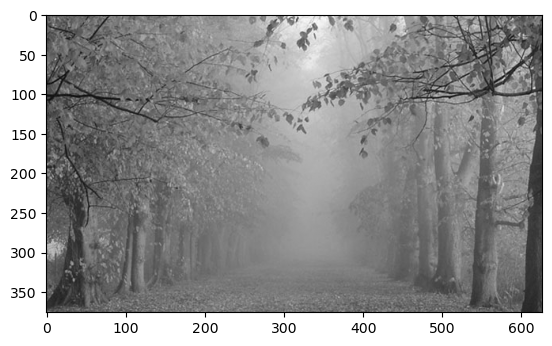

In [4]:
f = io.imread("haze.png")
f = clr.rgb2gray(f)
plt.imshow(f, cmap="gray")
plt.show()

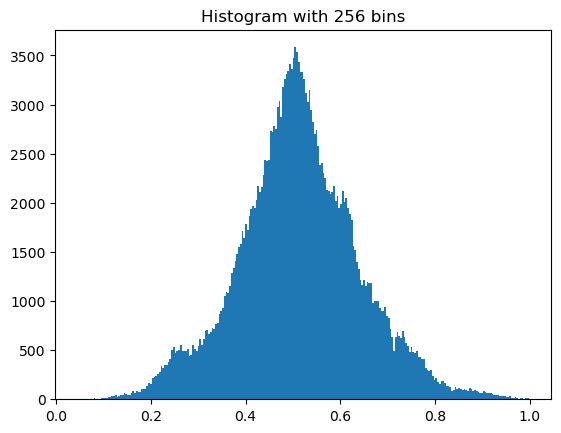

In [5]:
plt.figure()
plt.hist( np.ravel(f), bins=256)
plt.title("Histogram with 256 bins")
plt.show()

The original image and its histogram are given above.
The histogram is mono-modal (it has only one maximum) and uses the full range of intensities quite well.
However, there are few pixels with low or high intensities, explaining the lack of contrast in the image.

Thus, what is the effect on this image of a histogram spread?

### Multiplication by a real

By multiplying the intensities by a coefficient (here: 1.3), the histogram is dilated: low intensities stay weak while high intensities increase.
Therefore the image is lighter, but the dark areas are little changed.
As a result, the contrast is better.
Note that the two images are represented with intensities between 0 (`vmin`) and 1 (`vmax`).

Is this observation still valid for other values of the multiplicative coefficient?

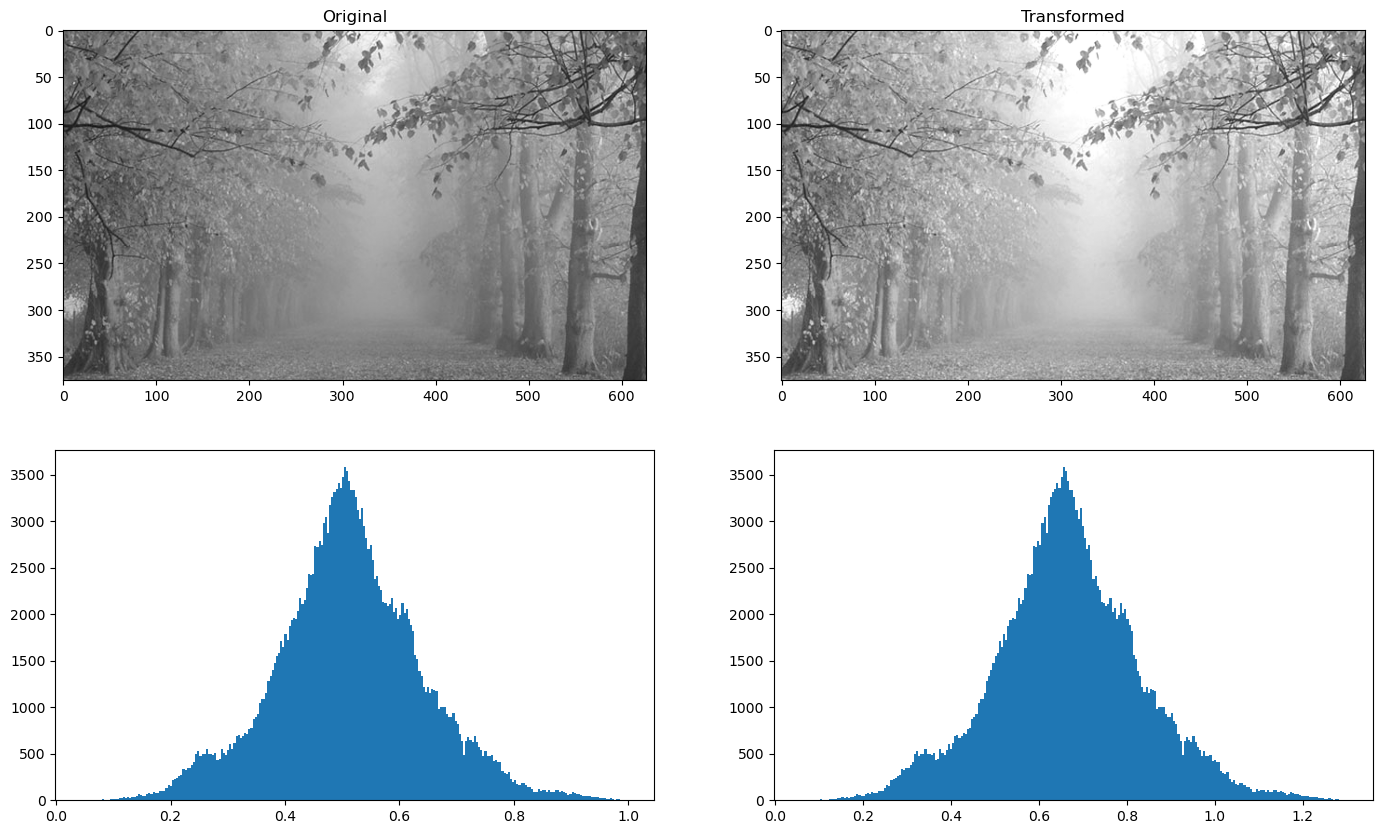

In [6]:
g = 1.3 * f

plt.figure(figsize=(17,10))

plt.subplot(2,2,1)
plt.imshow(f, cmap="gray", vmin=0.0, vmax=1.0)
plt.title('Original')

plt.subplot(2,2,2)
plt.imshow(g, cmap="gray", vmin=0.0, vmax=1.0)
plt.title('Transformed')

plt.subplot(2,2,3)
plt.hist( np.ravel(f), bins=256)

plt.subplot(2,2,4)
plt.hist( np.ravel(g), bins=256)

plt.show()

### Histogram equalization

The histogram equalization gives the result below.
The image is more contrasted than previously: this is due to the fact that the histogram of the transformed image is (almost) flat.

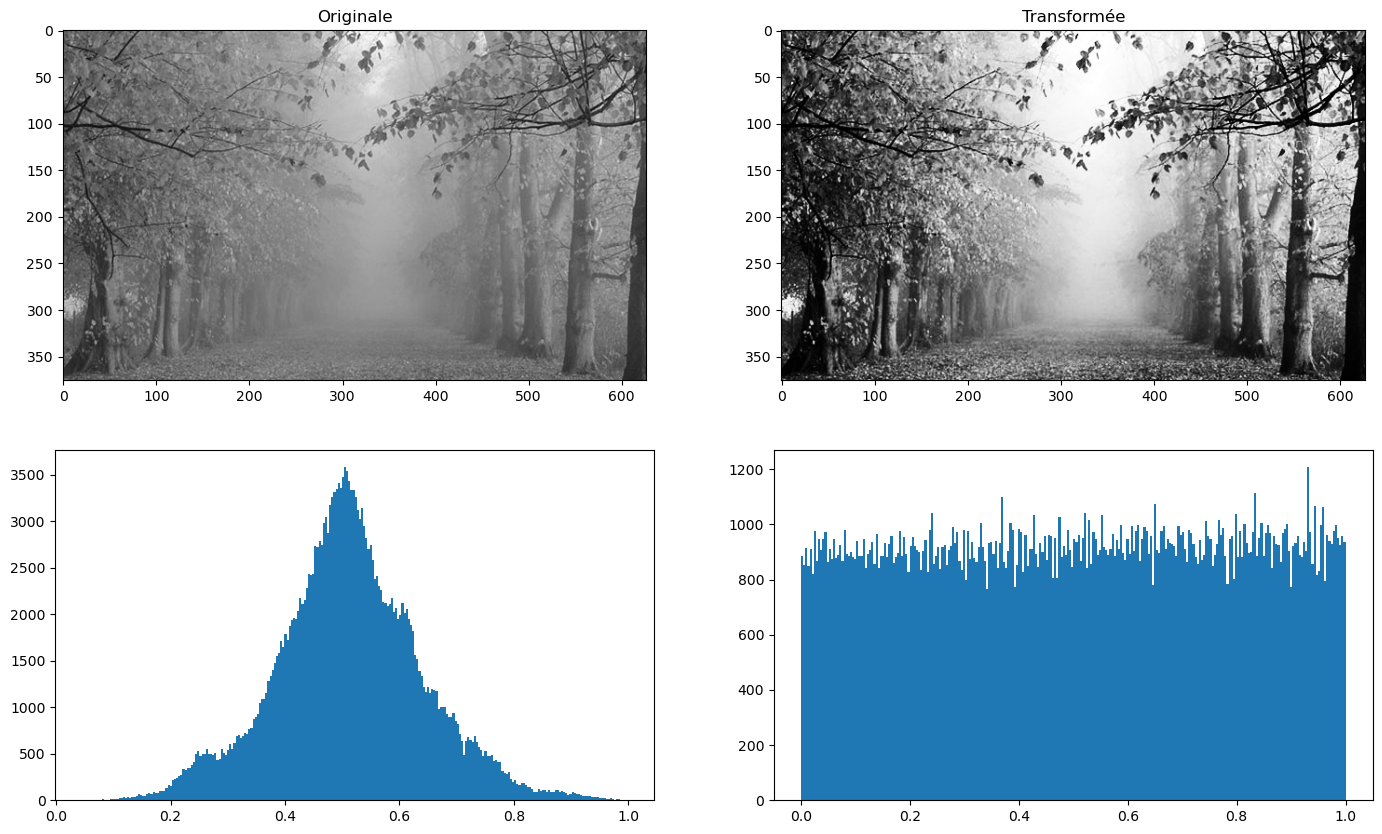

In [7]:
g = ex.equalize_hist(f)

plt.figure(figsize=(17,10))

plt.subplot(2,2,1)
plt.imshow(f, cmap="gray")
plt.title('Originale')

plt.subplot(2,2,2)
plt.imshow(g, cmap="gray")
plt.title('Transformée')

plt.subplot(2,2,3)
plt.hist( np.ravel(f), bins=256)

plt.subplot(2,2,4)
plt.hist( np.ravel(g), bins=256)

plt.show()